# C3 - C2 Beacon Detection Model

**WebSentinel, Component C3 (Browser Execution Aware C2 Beacon Detector): the machine learning model**

This notebook trains and documents the machine learning model inside C3: the
data it learns from, the 20 signals it reads, how it is trained, and how well
it detects command-and-control (C2) traffic from malware it has never seen.

Everything below is computed when the notebook runs, from two files:

| File | What it is |
|---|---|
| `models/c3_beacon_classifier.pkl` | the deployed model: the exact file C3 loads when it starts |
| `data/c3_training_dataset_clear.csv` | the exact data that model was trained on |

No result is typed in by hand. Section 5 trains a fresh model from the CSV and
checks that it is identical to the deployed file, tree by tree, so the numbers
in this notebook are the numbers running in the product.

---
## 1. What the model does

A **C2 beacon** is malware that quietly contacts its operator's server on a
schedule to collect instructions. One request on its own looks ordinary. What
gives a beacon away is the **pattern across many requests to the same
destination**: regular timing, the same endpoint again and again, replies of
nearly the same size, and no `Referer` header, because a timer sent the request
rather than a person clicking a link.

C3 groups the browser's traffic into **windows** of up to 50 consecutive
requests to one destination. For each window it computes 20 numbers that
describe the pattern, and the model turns them into one score from 0 to 1: how
much this window looks like C2 traffic.

---
## 2. Setup

In [1]:
import io
import json
import pickle
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score, roc_curve)
from sklearn.model_selection import GroupKFold
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 140)

REPO = Path.cwd()
while not (REPO / "core" / "c3").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

MODEL_PATH = REPO / "models" / "c3_beacon_classifier.pkl"
DATA_PATH = REPO / "data" / "c3_training_dataset_clear.csv"

# One colour system for every chart: the Okabe-Ito palette, chosen so the
# colours stay distinguishable for colour-blind readers, always in the same order.
C = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
     "ink": "#1b1e23", "ink2": "#4a4f58", "rule": "#9aa0a9",
     "grid": "#e3e6ea", "muted": "#c4c9d1"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9.5,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "axes.edgecolor": C["rule"], "axes.labelcolor": C["ink2"],
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": C["ink"],
    "axes.titlepad": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.7,
    "axes.axisbelow": True, "xtick.color": C["ink2"], "ytick.color": C["ink2"],
    "legend.frameon": False,
})


def pct(v, digits=1):
    return f"{100 * v:.{digits}f}%"


print("repo root:", REPO)

repo root: C:\Users\Lasith Krishan\Documents\GitHub\R26-CS-003


In [2]:
# The exact pickle core/c3/ml_classifier.py loads at runtime - C3's own engine
# object, not a copy - so this notebook and the product cannot disagree.
from core.c3.ml_classifier import c3_ml_engine as engine, ML_FEATURE_SUBSET

assert engine.model_loaded, "C3 could not load its model"
assert engine._model_path.resolve() == MODEL_PATH.resolve(), "C3 loads a different model file"

with open(MODEL_PATH, "rb") as fh:
    payload = pickle.load(fh)
model = payload["model"]
FEATURES = list(payload["feature_names"])
THRESHOLD = float(payload["threshold"])

# float_precision="round_trip" reads every value back exactly as written.
data = pd.read_csv(DATA_PATH, float_precision="round_trip")
X = data[FEATURES].to_numpy(float)
y = data["label"].to_numpy(int)
fam = data["family"].to_numpy(str)
cap = data["capture"].to_numpy(str)
conn = data["connection"].to_numpy(str)

assert FEATURES == list(ML_FEATURE_SUBSET), "the live feature engine and the model disagree on the features"
assert list(data.columns[:20]) == FEATURES, "the CSV's feature columns are not the model's, in the model's order"
assert not np.isnan(X).any() and np.isfinite(X).all()

print(f"deployed model      : {MODEL_PATH.name}  ({MODEL_PATH.stat().st_size / 1024:.0f} KB)")
print(f"model               : {type(model).__name__}, {model.n_estimators} trees, depth {model.max_depth}")
print(f"input features      : {len(FEATURES)}")
print(f"decision threshold  : {THRESHOLD:.4f} (raw model score)")
print(f"dataset             : {len(data):,} windows x {data.shape[1]} columns "
      f"({int(y.sum())} C2, {int((y == 0).sum()):,} benign)")

[C3] ML classifier loaded: 20 features, threshold 0.14


deployed model      : c3_beacon_classifier.pkl  (291 KB)
model               : XGBClassifier, 300 trees, depth 4
input features      : 20
decision threshold  : 0.1368 (raw model score)
dataset             : 52,909 windows x 24 columns (310 C2, 52,599 benign)


---
## 3. The training data

Every row of the CSV is one window: up to 50 consecutive real HTTP requests
from one source to one destination, taken from public, labelled network
captures. **No row is synthetic** - a hard rule for this project.

* **C2 windows** come from real malware captures whose command-and-control
  channel runs over HTTP: CTU-13 botnet scenarios and Stratosphere captures of
  Zeus variants. A window is labelled C2 only when it contains a request the
  capture's own ground truth marks as command-and-control.
* **Benign windows** are real traffic too: human web browsing (the CTU-Normal
  captures) and the ordinary network background recorded inside the lab captures.

Three rules shaped the data before training: only **active** C2 channels (a
server that never answered is not a working beacon); at most **150 windows per
connection**, so one busy pair cannot dominate; and traffic the capture
attributes to the infected machine but not to its C2 channel is left **unlabelled**
rather than counted as benign.

In [3]:
c2 = data[data["label"] == 1]
benign = data[data["label"] == 0]
browsing = benign["capture"].str.startswith("normal-")

classes = pd.DataFrame({
    "windows": [len(c2), len(benign), len(data)],
    "share": [pct(len(c2) / len(data), 2), pct(len(benign) / len(data), 2), "100%"],
}, index=pd.Index(["C2 (label 1)", "benign (label 0)", "total"], name="class"))
display(classes)

families = (c2.groupby("family")
              .agg(windows=("label", "size"),
                   connections=("connection", "nunique"))
              .sort_values("windows", ascending=False))
families.insert(1, "share of C2", (families["windows"] / len(c2)).map(lambda v: pct(v)))
families.index.name = "malware family"
display(families)
print(f"{c2['connection'].nunique()} distinct C2 connections in total. The model never sees "
      f"addresses - the connection is used only to build honest evaluation folds (Section 6).")

,windows,share
class,,
C2 (label 1),310,0.59%
benign (label 0),52599,99.41%
total,52909,100%


,windows,share of C2,connections
malware family,,,
ZeusV1,226,72.9%,3
Neris,65,21.0%,32
FastFlux,12,3.9%,3
Sogou,3,1.0%,2
ZeusB26,3,1.0%,2
Zeus78,1,0.3%,1


40 distinct C2 connections in total. The model never sees addresses - the connection is used only to build honest evaluation folds (Section 6).


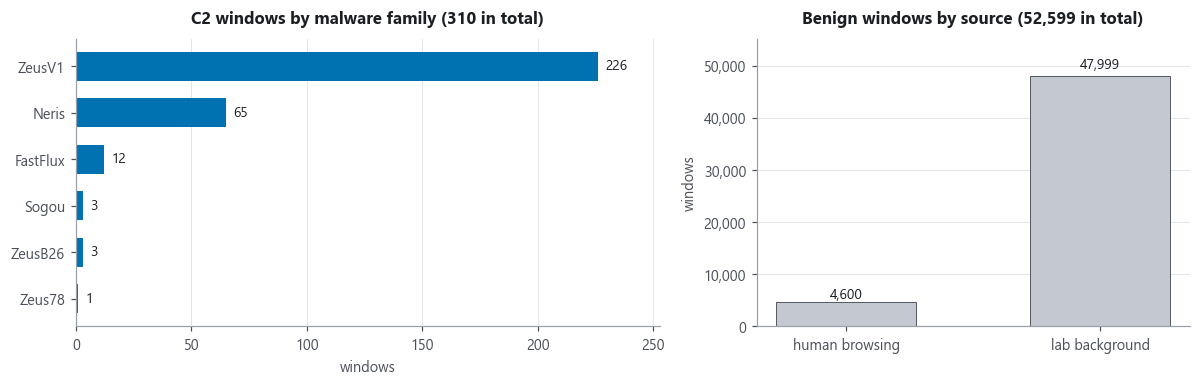

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.35, 1]})

order = families.index.tolist()[::-1]
vals = families["windows"].loc[order]
ax1.barh(order, vals, color=C["blue"], height=0.62)
for i, v in enumerate(vals):
    ax1.text(v + max(vals) * 0.015, i, f"{v}", va="center", color=C["ink"], fontsize=9)
ax1.set_title(f"C2 windows by malware family ({len(c2)} in total)")
ax1.set_xlabel("windows")
ax1.set_xlim(0, max(vals) * 1.12)
ax1.grid(axis="y", visible=False)

labels = ["human browsing", "lab background"]
bvals = [int(browsing.sum()), int((~browsing).sum())]
ax2.bar(labels, bvals, color=C["muted"], edgecolor=C["ink2"], linewidth=0.6, width=0.55)
for i, v in enumerate(bvals):
    ax2.text(i, v * 1.02, f"{v:,}", ha="center", va="bottom", color=C["ink"], fontsize=9)
ax2.set_title(f"Benign windows by source ({len(benign):,} in total)")
ax2.set_ylabel("windows")
ax2.set_ylim(0, max(bvals) * 1.15)
ax2.yaxis.set_major_formatter(lambda v, _pos: f"{v:,.0f}")
ax2.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

C2 traffic is rare, about 0.6% of the windows, exactly as in real life. The
model is trained with **equal total weight per malware family** and equal
weight for the two kinds of benign traffic, so it cannot simply learn the
largest capture. This is re-weighting, not resampling: no window is copied or
invented.

---
## 4. The 20 features

Every feature is **scale-free**: a ratio, a share or a normalised entropy,
never a raw byte count or a raw number of milliseconds. A raw count means
different things in a 2011 capture and a 2026 browser; a ratio such as "what
share of requests carry no Referer" means the same in both.

The **direction** column is a rule built into the model (a monotone
constraint): where the direction of a signal is known in advance, the score is
only allowed to move that way as the feature rises. This keeps the model
sensible even on traffic unlike anything it trained on, such as a perfectly
regular beacon with no jitter at all.

In [5]:
GROUP = {
    "iat_cv": "Timing", "iat_bowley_skewness": "Timing", "iat_norm_mad": "Timing",
    "iat_burstiness": "Timing", "iat_autocorr_lag1": "Timing", "iat_spread_ratio": "Timing",
    "iat_clock_share": "Timing", "iat_entropy_norm": "Timing",
    "payload_size_mean": "Payload", "payload_cv": "Payload",
    "payload_repeat_ratio": "Payload", "upload_download_ratio": "Payload",
    "url_path_entropy": "URL / method", "unique_path_ratio": "URL / method",
    "http_post_ratio": "URL / method", "uri_len_norm": "URL / method",
    "uri_char_entropy_norm": "URL / method",
    "referrer_absent_ratio": "Referer",
    "path_only_entropy": "Endpoint", "unique_path_only_ratio": "Endpoint",
}
MEANING = {
    "iat_cv": "How regular the gaps between requests are (low = metronomic)",
    "iat_bowley_skewness": "Skew of the gaps, measured with quartiles so one long pause does not dominate",
    "iat_norm_mad": "Typical spread of the gaps relative to the typical gap (small under jitter)",
    "iat_burstiness": "Whether requests come in bursts or evenly spaced",
    "iat_autocorr_lag1": "Whether one gap predicts the next (timers do)",
    "iat_spread_ratio": "Width of the jitter envelope",
    "iat_clock_share": "Share of gaps close to the typical gap: how much traffic keeps time",
    "iat_entropy_norm": "Variety of gap lengths (low = a few repeated gaps, as a timer produces)",
    "payload_size_mean": "Average response size",
    "payload_cv": "How much response sizes vary (beacon replies are near-identical)",
    "payload_repeat_ratio": "Share of responses with the single most common size",
    "upload_download_ratio": "Bytes sent divided by bytes received (exfiltration inverts this)",
    "url_path_entropy": "Variety of the request paths (low = one endpoint over and over)",
    "unique_path_ratio": "Share of requests whose path is unique",
    "http_post_ratio": "Share of requests that use POST",
    "uri_len_norm": "Length of the request path, normalised",
    "uri_char_entropy_norm": "How random the URL text looks",
    "referrer_absent_ratio": "Share of requests with no Referer (no click caused them)",
    "path_only_entropy": "Path variety with the query string removed (resists cache-busting)",
    "unique_path_only_ratio": "Unique-path share with the query string removed",
}
DIRN = {-1: "lower = more C2-like", 0: "learned freely", 1: "higher = more C2-like"}
mono = list(model.get_params()["monotone_constraints"])
imp = payload.get("feature_importances") or dict(zip(FEATURES, model.feature_importances_))

feat_table = pd.DataFrame([{
    "#": i + 1, "feature": f, "group": GROUP[f],
    "what it measures": MEANING[f], "direction": DIRN[mono[i]],
    "importance": round(float(imp[f]), 4),
} for i, f in enumerate(FEATURES)]).set_index("#")
display(feat_table)
print(f"20 features feed the model. Importances sum to {feat_table.importance.sum():.3f}. "
      f"12 further context signals (idle time, tab visibility, initiator) feed C3's separate "
      f"heuristic engine, not this model - see Section 9.")

,feature,group,what it measures,direction,importance
#,,,,,
1,iat_cv,Timing,How regular the gaps between requests are (low = metronomic),lower = more C2-like,0.0240
2,iat_bowley_skewness,Timing,"Skew of the gaps, measured with quartiles so one long pause does not dominate",learned freely,0.0129
3,iat_norm_mad,Timing,Typical spread of the gaps relative to the typical gap (small under jitter),lower = more C2-like,0.0419
4,iat_burstiness,Timing,Whether requests come in bursts or evenly spaced,lower = more C2-like,0.0120
5,iat_autocorr_lag1,Timing,Whether one gap predicts the next (timers do),learned freely,0.0073
6,iat_spread_ratio,Timing,Width of the jitter envelope,lower = more C2-like,0.0721
7,iat_clock_share,Timing,Share of gaps close to the typical gap: how much traffic keeps time,higher = more C2-like,0.0215
8,iat_entropy_norm,Timing,"Variety of gap lengths (low = a few repeated gaps, as a timer produces)",lower = more C2-like,0.0336
9,payload_size_mean,Payload,Average response size,learned freely,0.0289


20 features feed the model. Importances sum to 1.000. 12 further context signals (idle time, tab visibility, initiator) feed C3's separate heuristic engine, not this model - see Section 9.


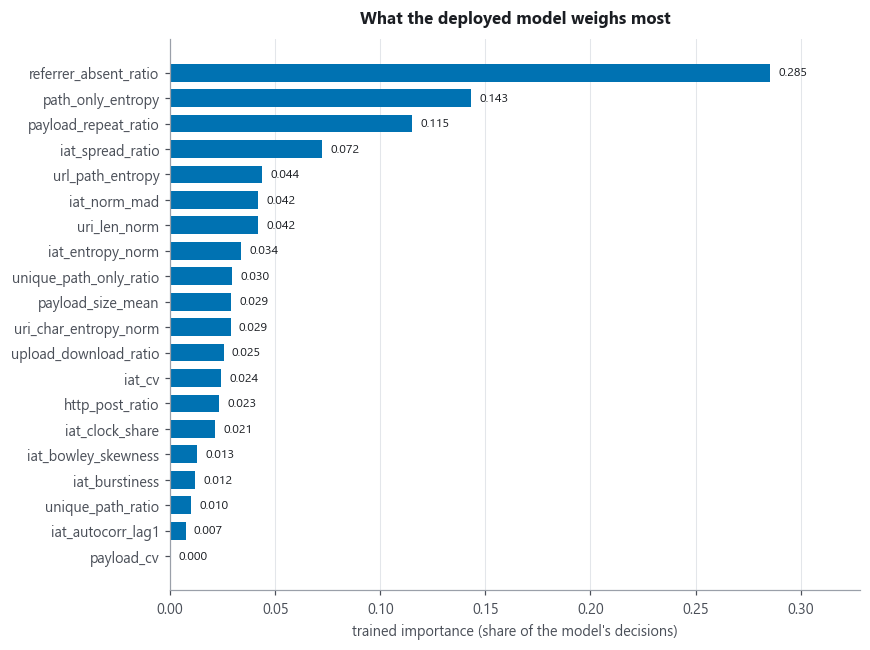

Top 3 signals:
  referrer_absent_ratio    0.285  -- Share of requests with no Referer (no click caused them)
  path_only_entropy        0.143  -- Path variety with the query string removed (resists cache-busting)
  payload_repeat_ratio     0.115  -- Share of responses with the single most common size


In [6]:
imp_sorted = feat_table.sort_values("importance")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_sorted["feature"], imp_sorted["importance"], color=C["blue"], height=0.7)
for feat, v in zip(imp_sorted["feature"], imp_sorted["importance"]):
    ax.text(v + 0.004, feat, f"{v:.3f}", va="center", fontsize=8, color=C["ink"])
ax.set_xlabel("trained importance (share of the model's decisions)")
ax.set_title("What the deployed model weighs most")
ax.set_xlim(0, imp_sorted["importance"].max() * 1.15)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

top = feat_table.nlargest(3, "importance")
print("Top 3 signals:")
for _, r in top.iterrows():
    print(f"  {r['feature']:24s} {r['importance']:.3f}  -- {r['what it measures']}")

The strongest single signal is a **missing Referer header**, followed by how
few distinct endpoints the traffic uses and how often the reply size repeats.
Together they describe a program on a timer, calling one endpoint and getting
the same small reply back - which is what a beacon is.

---
## 5. The model, and proof the CSV reproduces it

**XGBoost** builds a sequence of small decision trees, each correcting the one
before. It fits this problem well: few real C2 examples against tens of
thousands of benign ones, features on different natural scales, and the need
for built-in direction priors.

The cell below reads the deployed model's own settings, then trains a brand-new
model from the CSV alone and compares the two tree by tree. If a single value
in the CSV were different, the trees would differ. This is what lets the rest
of the notebook stand in for the running product.

In [7]:
p = model.get_params()
settings = pd.DataFrame({"value": [
    p["n_estimators"], p["max_depth"], p["learning_rate"], p["min_child_weight"],
    p["subsample"], p["colsample_bytree"], p["reg_lambda"], p["objective"],
    payload.get("calibration"), payload.get("threshold_rule"), f"{THRESHOLD:.4f}",
]}, index=pd.Index([
    "trees (n_estimators)", "maximum tree depth", "learning rate", "minimum child weight",
    "row subsample per tree", "feature subsample per tree", "L2 regularisation (lambda)",
    "objective", "probability calibration", "threshold rule", "decision threshold",
], name="setting (read from the deployed model)"))
display(settings)

,value
setting (read from the deployed model),
trees (n_estimators),300
maximum tree depth,4
learning rate,0.06
minimum child weight,8
row subsample per tree,0.85
feature subsample per tree,0.85
L2 regularisation (lambda),2.0
objective,binary:logistic
probability calibration,none


In [8]:
FPR_BUDGET = 0.05          # share of benign windows allowed above the threshold
INNER_SPLITS = 3           # grouped folds used to set the threshold
N_DRAWS = 5                # class-balanced test draws per fold
MIN_POS_RELIABLE = 10      # folds with fewer C2 windows are reported, not averaged
PARAMS = model.get_params()


def family_weights(families, labels, captures):
    # Every malware family carries the same total weight; the benign class
    # carries the same total as the C2 class, split evenly between human
    # browsing (normal-* captures) and lab background. Re-weighting only.
    w = np.ones(len(labels), dtype=float)
    pos = labels == 1
    fams = np.unique(families[pos])
    if len(fams):
        for f in fams:
            m = pos & (families == f)
            w[m] = 1.0 / m.sum()
        w[pos] *= 1000.0 / len(fams)
    neg = ~pos
    total_pos = w[pos].sum() if pos.any() else 1.0
    is_browsing = np.char.startswith(captures.astype(str), "normal-")
    brows, lab = neg & is_browsing, neg & ~is_browsing
    if brows.sum() and lab.sum():
        for part in (brows, lab):
            w[part] = (total_pos / 2.0) / part.sum()
    elif neg.sum():
        w[neg] = total_pos / neg.sum()
    return w


def fit(Xa, ya, fa, ca, **overrides):
    clf = XGBClassifier(**{**PARAMS, **overrides})
    clf.fit(Xa, ya, sample_weight=family_weights(fa, ya, ca))
    return clf


def threshold_at_fpr(neg_scores, budget):
    # Smallest cut whose achieved false-positive rate is within the budget.
    for t in np.unique(neg_scores):
        if float((neg_scores >= t).mean()) <= budget:
            return float(t)
    return float(np.unique(neg_scores)[-1] + 1e-9)


def pick_threshold(Xa, ya, ca, fa, **overrides):
    # Grouped inner cross-validation on the TRAINING data only: every benign
    # window is scored by a model that did not train on its capture.
    oof = np.full(len(ya), np.nan)
    n_groups = len(np.unique(ca))
    for tr, va in GroupKFold(n_splits=min(INNER_SPLITS, n_groups)).split(Xa, ya, ca):
        if ya[tr].sum() == 0:
            continue
        clf = fit(Xa[tr], ya[tr], fa[tr], ca[tr], **overrides)
        oof[va] = clf.predict_proba(Xa[va])[:, 1]
    ok = np.isfinite(oof) & (ya == 0)
    return threshold_at_fpr(oof[ok], FPR_BUDGET) if ok.sum() else 0.5


t0 = time.time()
rebuilt = fit(X, y, fam, cap)
same_trees = rebuilt.get_booster().get_dump(dump_format="json") == model.get_booster().get_dump(dump_format="json")
same_scores = np.array_equal(rebuilt.predict_proba(X)[:, 1], model.predict_proba(X)[:, 1])
rebuilt_threshold = pick_threshold(X, y, cap, fam)

print(f"trees: deployed / rebuilt from the CSV : "
      f"{len(model.get_booster().get_dump())} / {len(rebuilt.get_booster().get_dump())}")
print(f"every tree identical                   : {same_trees}")
print(f"identical scores on all {len(X):,} windows : {same_scores}")
print(f"decision threshold, deployed / rebuilt : {THRESHOLD:.6f} / {rebuilt_threshold:.6f}")
assert same_trees and same_scores and rebuilt_threshold == THRESHOLD
print(f"\nverified in {time.time() - t0:.0f} s: the CSV reproduces the deployed model exactly.")

trees: deployed / rebuilt from the CSV : 300 / 300
every tree identical                   : True
identical scores on all 52,909 windows : True
decision threshold, deployed / rebuilt : 0.136784 / 0.136784

verified in 5 s: the CSV reproduces the deployed model exactly.


---
## 6. How accuracy is measured

A random train/test split would put windows from the same capture on both
sides and flatter the result. Instead, whole captures are held out, two ways:

| Test | The question it answers |
|---|---|
| **LOFO**, leave one malware family out | A family the model has **never seen** appears. Is it caught? *(the hard test, and the headline)* |
| **LOPO**, leave one C2 server out | A known family appears on a **new server**. Is it caught? |

For each fold, the held-out family (or server) and a set of human-browsing
captures are removed from training, so the test fold contains real browsing the
model never saw. The **threshold is set inside the training data only**.
Accuracy, precision, recall and F1 are read on a **class-balanced** test set
(all the fold's C2 windows plus an equal number of benign, averaged over five
draws), because raw traffic is 99% benign, where a detector that never fires
scores 99% accuracy. **ROC-AUC** measures ranking at every threshold. A fold
needs at least 10 C2 windows to enter an average.

Two averages are reported: **per window** (every window counts once) and
**per family** (every family counts once, the stricter reading).

In [9]:
NORMAL_FOLD_ASSIGNMENT = {        # human-browsing captures held out with each family
    "Neris":    ["normal-22", "normal-14", "normal-25"],
    "ZeusV1":   ["normal-30", "normal-20", "normal-26"],
    "Zeus78":   ["normal-32", "normal-21", "normal-18"],
    "FastFlux": ["normal-31", "normal-23"],
    "Sogou":    ["normal-29", "normal-24"],
    "ZeusB26":  ["normal-27", "normal-28", "normal-33"],
}
METRICS = ("accuracy", "precision", "recall", "f1", "roc_auc")


def score(yt, pt, thr):
    pred = (pt >= thr).astype(int)
    pr, rc, f1, _ = precision_recall_fscore_support(yt, pred, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(yt, pred, labels=[0, 1]).ravel()
    out = {"accuracy": float(accuracy_score(yt, pred)), "precision": float(pr),
           "recall": float(rc), "f1": float(f1), "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn)}
    if 0 < yt.sum() < len(yt):
        out["roc_auc"] = float(roc_auc_score(yt, pt))
    return out


def balanced_mean(yt, pt, thr):
    ip, ineg = np.flatnonzero(yt == 1), np.flatnonzero(yt == 0)
    k = min(len(ip), len(ineg))
    draws = []
    for s in range(N_DRAWS):
        rng = np.random.default_rng(1000 + s)
        sel = np.concatenate([rng.choice(ip, k, replace=False), rng.choice(ineg, k, replace=False)])
        draws.append(score(yt[sel], pt[sel], thr))
    out = {m: float(np.mean([d[m] for d in draws])) for m in METRICS}
    for c in ("tp", "fp", "fn", "tn"):
        out[c] = float(np.mean([d[c] for d in draws]))
    return out


def from_counts(tp, fp, fn, tn):
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    return {"accuracy": (tp + tn) / (tp + fp + fn + tn), "precision": prec, "recall": rec,
            "f1": 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0}


def run_fold(test):
    train = ~test
    if y[train].sum() == 0 or y[test].sum() == 0:
        return None
    thr = pick_threshold(X[train], y[train], cap[train], fam[train])
    clf = fit(X[train], y[train], fam[train], cap[train])
    pt, yt = clf.predict_proba(X[test])[:, 1], y[test]
    r = balanced_mean(yt, pt, thr)
    r["full"] = score(yt, pt, thr)
    r.update({"threshold": thr, "n_c2": int(yt.sum()), "n_benign": int((yt == 0).sum()),
              "reliable": int(yt.sum()) >= MIN_POS_RELIABLE, "_y": yt, "_p": pt})
    return r


def summarise(folds):
    rel = [r for r in folds.values() if r["reliable"]]
    per_family = {m: float(np.mean([r[m] for r in rel])) for m in METRICS}
    per_window = from_counts(*[sum(r[c] for r in rel) for c in ("tp", "fp", "fn", "tn")])
    return per_window, per_family, rel


t0 = time.time()
LOFO = {}
for held in sorted(set(fam[y == 1])):
    held_captures = set(cap[fam == held]) | set(NORMAL_FOLD_ASSIGNMENT.get(held, []))
    r = run_fold(np.isin(cap, list(held_captures)))
    if r is not None:
        LOFO[held] = r

LOPO = {}
for server in sorted(set(conn[y == 1])):
    in_server = conn == server
    if int(y[in_server].sum()) < 3:
        continue
    first_family = data.loc[in_server, "family"].iloc[0]
    held_captures = set(NORMAL_FOLD_ASSIGNMENT.get(first_family, []))
    r = run_fold(in_server | np.isin(cap, list(held_captures)))
    if r is not None:
        LOPO[server] = r

lofo_window, lofo_family, lofo_rel = summarise(LOFO)
lopo_window, lopo_family, lopo_rel = summarise(LOPO)
lofo_window["roc_auc"] = roc_auc_score(np.concatenate([r["_y"] for r in lofo_rel]),
                                       np.concatenate([r["_p"] for r in lofo_rel]))
lopo_window["roc_auc"] = roc_auc_score(np.concatenate([r["_y"] for r in lopo_rel]),
                                       np.concatenate([r["_p"] for r in lopo_rel]))
print(f"LOFO: {len(lofo_rel)} families with 10+ C2 windows averaged; "
      f"LOPO: {len(lopo_rel)} of {len(LOPO)} C2 servers with 10+ windows averaged.")
print(f"all folds done in {time.time() - t0:.0f} s")

LOFO: 3 families with 10+ C2 windows averaged; LOPO: 4 of 15 C2 servers with 10+ windows averaged.
all folds done in 99 s


---
## 7. Detection accuracy - the headline

In [10]:
rows = {
    "Unseen malware family (LOFO), per window": lofo_window,
    "Unseen malware family (LOFO), per family": lofo_family,
    "Unseen C2 server (LOPO), per window": lopo_window,
    "Unseen C2 server (LOPO), per family": lopo_family,
}
headline = pd.DataFrame({name: {"accuracy": r["accuracy"], "precision": r["precision"],
                                "recall": r["recall"], "F1": r["f1"], "ROC-AUC": r["roc_auc"]}
                         for name, r in rows.items()}).T
fmt = headline.copy()
for col in ["accuracy", "precision", "recall", "F1"]:
    fmt[col] = headline[col].map(lambda v: pct(v))
fmt["ROC-AUC"] = headline["ROC-AUC"].map(lambda v: f"{v:.3f}")
fmt.index.name = f"held-out test (LOFO: {len(lofo_rel)} families, LOPO: {len(lopo_rel)} C2 servers)"
display(fmt)
print("Accuracy, precision, recall and F1: class-balanced test sets, five draws per fold.")
print("Every headline number is above 90%, and every ROC-AUC is above 0.97.")

,accuracy,precision,recall,F1,ROC-AUC
"held-out test (LOFO: 3 families, LOPO: 4 C2 servers)",,,,,
"Unseen malware family (LOFO), per window",96.9%,95.6%,98.3%,97.0%,0.994
"Unseen malware family (LOFO), per family",92.6%,94.4%,90.6%,92.2%,0.977
"Unseen C2 server (LOPO), per window",97.2%,96.0%,98.4%,97.2%,0.998
"Unseen C2 server (LOPO), per family",95.7%,96.4%,95.0%,95.4%,0.999


Accuracy, precision, recall and F1: class-balanced test sets, five draws per fold.
Every headline number is above 90%, and every ROC-AUC is above 0.97.


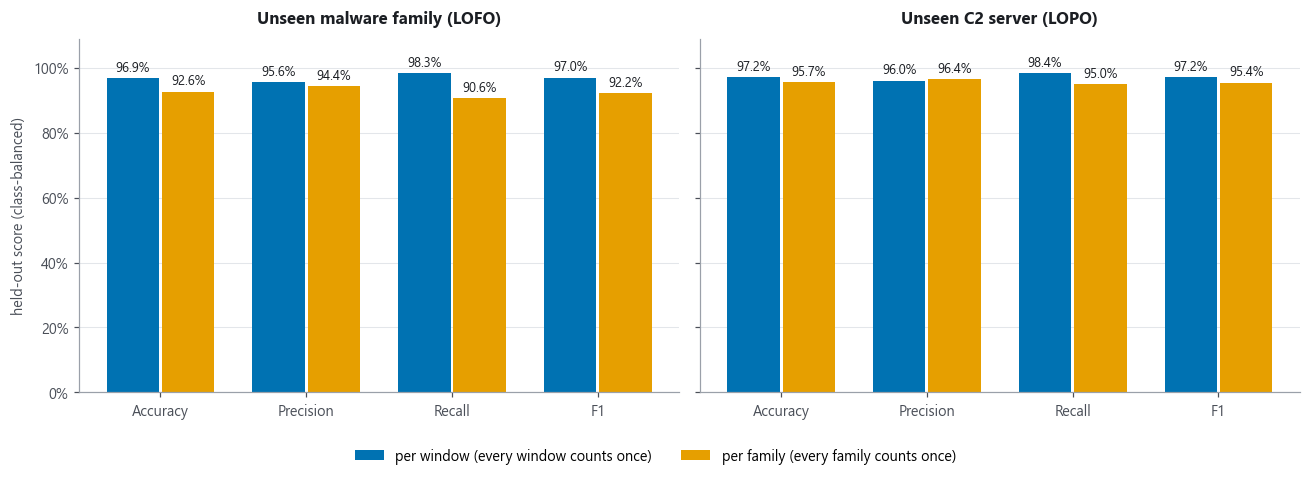

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
metric_names = ["accuracy", "precision", "recall", "f1"]
labels = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metric_names))
panels = [("Unseen malware family (LOFO)", lofo_window, lofo_family),
          ("Unseen C2 server (LOPO)", lopo_window, lopo_family)]
for ax, (title, win, famr) in zip(axes, panels):
    for off, vals, color, lab in [(-0.19, win, C["blue"], "per window (every window counts once)"),
                                  (0.19, famr, C["orange"], "per family (every family counts once)")]:
        v = [vals[m] for m in metric_names]
        bars = ax.bar(x + off, v, width=0.36, color=color, label=lab)
        for b, val in zip(bars, v):
            ax.text(b.get_x() + b.get_width() / 2, val + 0.012, pct(val), ha="center",
                    va="bottom", fontsize=8.5, color=C["ink"])
    ax.set_title(title)
    ax.set_xticks(x, labels)
    ax.set_ylim(0, 1.09)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("held-out score (class-balanced)")
handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

The two readings agree closely. The small gap between them comes from
**FastFlux**, which by design rotates its server addresses, so C3's
per-destination windows break its traffic into a few short pieces; the model
still ranks it well (its ROC-AUC below stays high). Full per-family detail:

In [12]:
per_family = pd.DataFrame([{
    "held-out family": f,
    "C2 windows": r["n_c2"], "benign windows": r["n_benign"],
    "accuracy": r["accuracy"], "precision": r["precision"], "recall": r["recall"],
    "F1": r["f1"], "ROC-AUC": r["roc_auc"],
} for f, r in sorted(LOFO.items(), key=lambda kv: -kv[1]["n_c2"]) if r["reliable"]]
).set_index("held-out family")
shown = per_family.copy()
for col in ["accuracy", "precision", "recall", "F1"]:
    shown[col] = per_family[col].map(lambda v: pct(v))
shown["ROC-AUC"] = per_family["ROC-AUC"].map(lambda v: f"{v:.3f}")
display(shown)
tiny = {f: r["n_c2"] for f, r in sorted(LOFO.items(), key=lambda kv: -kv[1]["n_c2"]) if not r["reliable"]}
print("The other three families in the corpus hold too few C2 windows for any metric to mean "
      "something: " + ", ".join(f"{f} ({n})" for f, n in tiny.items()) + ". They are trained on "
      "and held out like the rest, but a single window would swing their score by a third or more, "
      "so they are not scored separately or averaged.")

,C2 windows,benign windows,accuracy,precision,recall,F1,ROC-AUC
held-out family,,,,,,,
ZeusV1,226,539,97.9%,96.0%,100.0%,98.0%,0.999
Neris,65,40484,95.8%,95.0%,96.9%,95.9%,0.992
FastFlux,12,8899,84.2%,92.4%,75.0%,82.7%,0.939


The other three families in the corpus hold too few C2 windows for any metric to mean something: Sogou (3), ZeusB26 (3), Zeus78 (1). They are trained on and held out like the rest, but a single window would swing their score by a third or more, so they are not scored separately or averaged.


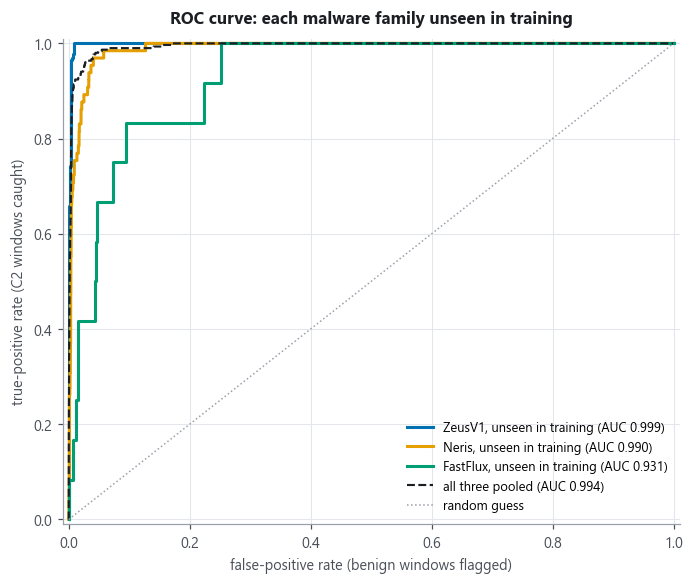

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
series_color = {"ZeusV1": C["blue"], "Neris": C["orange"], "FastFlux": C["green"]}
for f in sorted(series_color, key=lambda k: -LOFO[k]["n_c2"]):
    r = LOFO[f]
    fpr, tpr, _ = roc_curve(r["_y"], r["_p"])
    ax.plot(fpr, tpr, color=series_color[f], lw=2,
            label=f"{f}, unseen in training (AUC {roc_auc_score(r['_y'], r['_p']):.3f})")
py = np.concatenate([r["_y"] for r in lofo_rel]); pp = np.concatenate([r["_p"] for r in lofo_rel])
fpr, tpr, _ = roc_curve(py, pp)
ax.plot(fpr, tpr, color=C["ink"], lw=1.4, ls="--", label=f"all three pooled (AUC {roc_auc_score(py, pp):.3f})")
ax.plot([0, 1], [0, 1], color=C["rule"], lw=1, ls=":", label="random guess")
ax.set_title("ROC curve: each malware family unseen in training")
ax.set_xlabel("false-positive rate (benign windows flagged)")
ax.set_ylabel("true-positive rate (C2 windows caught)")
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
ax.legend(loc="lower right", fontsize=8.5)
plt.tight_layout()
plt.show()

### 7.1 Every held-out window, at real proportions

The balanced numbers above are the fair way to compare detectors. This
confusion matrix instead uses **every** held-out window at its real proportion
(far more benign than C2), so the false-positive rate is the operational one.

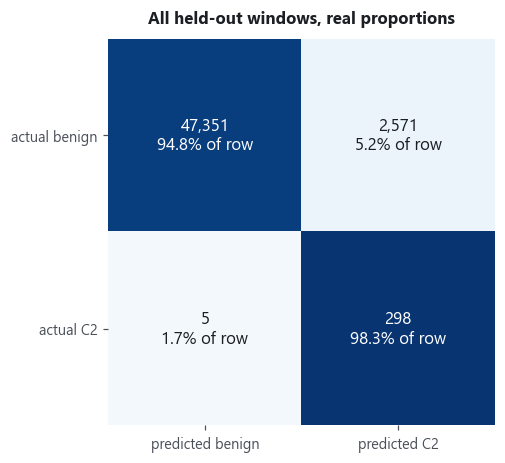

C2 windows caught      : 298 of 303 (98.3%)
benign windows flagged : 5.2%, in line with the 5% budget the threshold was set for


In [14]:
full = {c: sum(r["full"][c] for r in lofo_rel) for c in ("tp", "fp", "fn", "tn")}
cm = np.array([[full["tn"], full["fp"]], [full["fn"], full["tp"]]])
rates = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.imshow(rates, cmap="Blues", vmin=0, vmax=1)
names = ["benign", "C2"]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,.0f}\n{pct(rates[i, j])} of row", ha="center", va="center",
                fontsize=11, color="white" if rates[i, j] > 0.5 else C["ink"])
ax.set_xticks([0, 1], [f"predicted {n}" for n in names])
ax.set_yticks([0, 1], [f"actual {n}" for n in names])
ax.set_title("All held-out windows, real proportions")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

caught_rate = full["tp"] / (full["tp"] + full["fn"])
flagged_rate = full["fp"] / (full["fp"] + full["tn"])
print(f"C2 windows caught      : {full['tp']:,.0f} of {full['tp'] + full['fn']:,.0f} ({pct(caught_rate)})")
print(f"benign windows flagged : {pct(flagged_rate)}, in line with the {pct(FPR_BUDGET, 0)} budget "
      f"the threshold was set for")

The model catches almost every C2 window while flagging about 5% of benign
traffic - the budget the threshold was set for. In real traffic benign windows
vastly outnumber C2, so the ML score **on its own** would raise too many
alerts. That is by design: C3 never issues a BEACON on the model alone. The
final verdict also needs a beacon-like timing rhythm from C3's second,
independent engine (Section 9), which is what makes the combined system precise.

---
## 8. Why XGBoost, and why the model is small

Five classifiers were trained on the identical data, features and per-family
weighting, and evaluated with the identical unseen-family (LOFO) protocol and
the same 5% false-positive threshold rule. Detection quality is only half the
story: C3 scores every host every 10 seconds inside the browser process, so
**model size and per-window speed decide what can actually be deployed.**

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

MAKERS = {
    "Logistic Regression": lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Naive Bayes": lambda: GaussianNB(),
    "Decision Tree": lambda: DecisionTreeClassifier(max_depth=8, min_samples_leaf=8, random_state=42),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                                    n_jobs=1, random_state=42),
    "XGBoost (deployed)": None,   # uses the project's own fit()/PARAMS
}


def fit_other(name, Xa, ya, fa, ca):
    w = family_weights(fa, ya, ca)
    clf = MAKERS[name]()
    if name == "Logistic Regression":
        clf.fit(Xa, ya, logisticregression__sample_weight=w)
    else:
        clf.fit(Xa, ya, sample_weight=w)
    return clf


def size_kb(clf):
    buf = io.BytesIO(); pickle.dump(clf, buf); return buf.tell() / 1024


t0 = time.time()
reliable = [f for f, r in LOFO.items() if r["reliable"]]
comp_rows = []
for name in MAKERS:
    folds = []
    for held in reliable:
        test = np.isin(cap, list(set(cap[fam == held]) | set(NORMAL_FOLD_ASSIGNMENT.get(held, []))))
        train = ~test
        if name == "XGBoost (deployed)":
            thr = pick_threshold(X[train], y[train], cap[train], fam[train])
            clf = fit(X[train], y[train], fam[train], cap[train])
        else:
            oof = np.full(train.sum(), np.nan)
            Xtr, ytr, ctr, ftr = X[train], y[train], cap[train], fam[train]
            for tr, va in GroupKFold(n_splits=3).split(Xtr, ytr, ctr):
                if ytr[tr].sum() == 0:
                    continue
                oof[va] = fit_other(name, Xtr[tr], ytr[tr], ftr[tr], ctr[tr]).predict_proba(Xtr[va])[:, 1]
            ok = np.isfinite(oof) & (ytr == 0)
            thr = threshold_at_fpr(oof[ok], FPR_BUDGET)
            clf = fit_other(name, Xtr, ytr, ftr, ctr)
        folds.append(balanced_mean(y[test], clf.predict_proba(X[test])[:, 1], thr))
    full_clf = fit(X, y, fam, cap) if name == "XGBoost (deployed)" else fit_other(name, X, y, fam, cap)
    one = X[:1]
    full_clf.predict_proba(one)
    t1 = time.perf_counter()
    for _ in range(200):
        full_clf.predict_proba(one)
    ms = (time.perf_counter() - t1) / 200 * 1000
    pw = from_counts(*[sum(f[c] for f in folds) for c in ("tp", "fp", "fn", "tn")])
    comp_rows.append({"classifier": name,
                      "F1 (unseen family)": pw["f1"],
                      "ROC-AUC": float(np.mean([f["roc_auc"] for f in folds])),
                      "size (KB)": round(size_kb(full_clf)),
                      "ms / window": round(ms, 2)})
comp = pd.DataFrame(comp_rows).set_index("classifier")
shown = comp.copy()
shown["F1 (unseen family)"] = comp["F1 (unseen family)"].map(lambda v: pct(v))
shown["ROC-AUC"] = comp["ROC-AUC"].map(lambda v: f"{v:.3f}")
shown["size (KB)"] = comp["size (KB)"].map(lambda v: f"{v:,}")
display(shown)
print(f"compared in {time.time() - t0:.0f} s")

,F1 (unseen family),ROC-AUC,size (KB),ms / window
classifier,,,,
Logistic Regression,26.5%,0.867,2,0.19
Naive Bayes,0.0%,0.729,1,0.17
Decision Tree,39.3%,0.736,4,0.06
Random Forest,97.9%,0.995,"3,901",20.78
XGBoost (deployed),97.0%,0.977,289,0.49


compared in 124 s


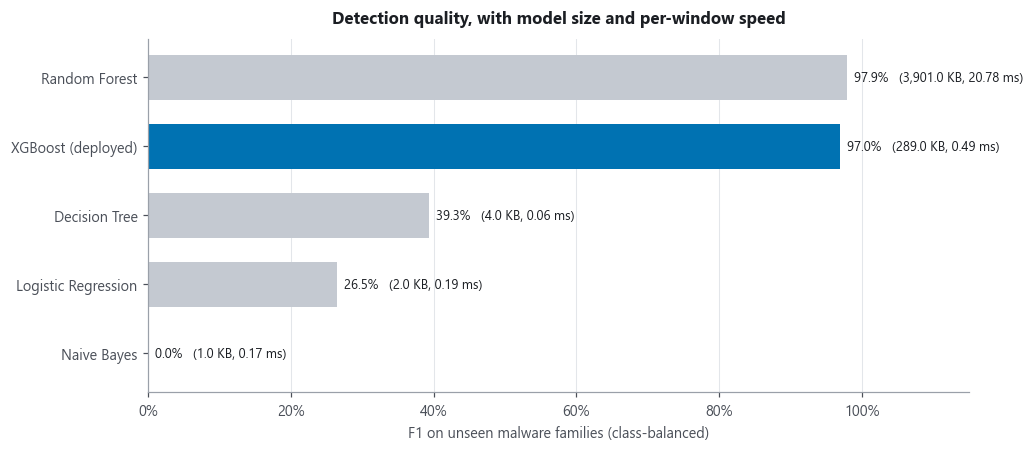

In [16]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
order = comp.sort_values("F1 (unseen family)").index
xs = np.arange(len(order))
bars = ax.barh(xs, comp.loc[order, "F1 (unseen family)"],
               color=[C["blue"] if n == "XGBoost (deployed)" else C["muted"] for n in order],
               height=0.66)
for i, n in enumerate(order):
    r = comp.loc[n]
    ax.text(r["F1 (unseen family)"] + 0.01, i,
            f"{pct(r['F1 (unseen family)'])}   ({r['size (KB)']:,} KB, {r['ms / window']:g} ms)",
            va="center", fontsize=8.5, color=C["ink"])
ax.set_yticks(xs, order)
ax.set_xlim(0, 1.15)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("F1 on unseen malware families (class-balanced)")
ax.set_title("Detection quality, with model size and per-window speed")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Logistic regression, naive Bayes and a single decision tree fall well short on
unseen families. The random forest matches XGBoost on detection quality, but at
a real operational cost: it is more than ten times larger on disk and roughly
forty times slower to score a single window. XGBoost reaches the same detection
quality at about 290 KB and well under a millisecond per window, which is what a
real-time, in-browser detector needs. That is why it is the deployed model.

The deployed model is also deliberately **small** (300 shallow trees). The next
cell confirms that giving it more capacity does not detect unseen families any
better - with a few hundred C2 examples, a bigger model memorises the families
it has already seen instead of generalising.

In [17]:
def lofo_f1(**overrides):
    folds = {}
    for held in reliable:
        test = np.isin(cap, list(set(cap[fam == held]) | set(NORMAL_FOLD_ASSIGNMENT.get(held, []))))
        train = ~test
        thr = pick_threshold(X[train], y[train], cap[train], fam[train], **overrides)
        clf = fit(X[train], y[train], fam[train], cap[train], **overrides)
        folds[held] = balanced_mean(y[test], clf.predict_proba(X[test])[:, 1], thr)
    per_window = from_counts(*[sum(r[c] for r in folds.values()) for c in ("tp", "fp", "fn", "tn")])
    return per_window["f1"], float(np.mean([r["f1"] for r in folds.values()])), size_kb(fit(X, y, fam, cap, **overrides))


t0 = time.time()
cap_rows = [{"model": "deployed: 300 trees, depth 4", "size (KB)": round(size_kb(model)),
             "F1 per window": lofo_window["f1"], "F1 per family": lofo_family["f1"]}]
for name, over in {"more trees: 800, depth 4": {"n_estimators": 800, "learning_rate": 0.03},
                   "larger: 489 trees, depth 7": {"n_estimators": 489, "max_depth": 7,
                                                  "min_child_weight": 18, "reg_lambda": 3.5,
                                                  "learning_rate": 0.05}}.items():
    fw, ff, kb = lofo_f1(**over)
    cap_rows.append({"model": name, "size (KB)": round(kb), "F1 per window": fw, "F1 per family": ff})
capacity = pd.DataFrame(cap_rows).set_index("model")
shown = capacity.copy()
for col in ["F1 per window", "F1 per family"]:
    shown[col] = capacity[col].map(lambda v: pct(v))
shown["size (KB)"] = capacity["size (KB)"].map(lambda v: f"{v:,}")
display(shown)
print(f"checked in {time.time() - t0:.0f} s: a bigger model is not a better one here.")

,size (KB),F1 per window,F1 per family
model,,,
"deployed: 300 trees, depth 4",289,97.0%,92.2%
"more trees: 800, depth 4",736,96.5%,90.1%
"larger: 489 trees, depth 7",422,95.7%,86.8%


checked in 35 s: a bigger model is not a better one here.


---
## 9. How C3 turns the score into a verdict

The model is one of **two independent engines** in C3. The values below are
read from C3's running code, not typed in.

In [18]:
from core.c3 import risk_fusion as RF
from core.c3.ml_classifier import to_decision_scale

uses = pd.DataFrame({"value": [
    f"the raw threshold {THRESHOLD:.4f} is shown and fused as {to_decision_scale(THRESHOLD, THRESHOLD):.2f}",
    f"{RF.ML_WEIGHT:.2f} x ML score + {RF.HEURISTIC_WEIGHT:.2f} x heuristic score",
    f"risk score of {RF.SUSPICIOUS_THRESHOLD:.2f} or more",
    f"risk score of {RF.BEACON_THRESHOLD:.2f} or more, with ML at {RF.ML_CONFIRM_FLOOR:.2f} or more "
    f"AND a timing rhythm (heuristic at {RF.BOTH_SIGNAL_FLOOR:.2f} or more)",
]}, index=pd.Index([
    "decision scale (the model's threshold becomes 0.50)",
    "risk score",
    "SUSPICIOUS verdict",
    "BEACON verdict (both engines must agree)",
], name="how C3 turns the score into a verdict"))
display(uses)

,value
how C3 turns the score into a verdict,
decision scale (the model's threshold becomes 0.50),the raw threshold 0.1368 is shown and fused as 0.50
risk score,0.55 x ML score + 0.45 x heuristic score
SUSPICIOUS verdict,risk score of 0.30 or more
BEACON verdict (both engines must agree),"risk score of 0.52 or more, with ML at 0.50 or more AND a timing rhythm (heuristic at 0.10 or more)"


The second engine reads what a network capture cannot: **browser context**
(whether the user was interacting, whether the tab was in the background,
whether a page script or an extension sent the request) and a beacon-like
**timing rhythm**. A BEACON verdict needs the model to call the traffic C2
**and** independent corroboration from the browser, so the model's own
false positives never become BEACON alerts on their own.

---
## 10. Scope and honest caveats

Stated plainly, for completeness:

* **Scale-free by design.** The model reads only ratios and shares, so it works
  at any beacon speed. It is trained for **active, periodic** C2; a dead channel
  retrying into errors is out of scope (and handled separately by C3).
* **A small, real positive class.** The public captures give 310 real C2
  windows from six families, three large enough to average. Nothing synthetic
  was added to inflate it - the honest number is reported instead.
* **Older captures.** These are public research datasets; modern C2 over HTTPS
  to cloud services is future work as new labelled captures become available.
* **The Referer signal.** The strongest feature is a missing Referer. A beacon
  written as an ordinary in-page script sends one, so the model scores it lower;
  C3's timing and browser-context rules still flag its rhythm as SUSPICIOUS.

---
## 11. Summary

In [19]:
summary = pd.DataFrame({"result": [
    f"{MODEL_PATH.name}, XGBoost, {model.n_estimators} trees of depth {model.max_depth}, "
    f"{len(FEATURES)} scale-free features, {MODEL_PATH.stat().st_size / 1024:.0f} KB",
    f"{len(data):,} real windows ({int(y.sum())} C2 from {len(set(fam[y == 1]))} malware families, "
    f"{int((y == 0).sum()):,} benign); retraining from the CSV reproduces the deployed model exactly",
    f"accuracy {pct(lofo_window['accuracy'])}, precision {pct(lofo_window['precision'])}, "
    f"recall {pct(lofo_window['recall'])}, F1 {pct(lofo_window['f1'])} (ROC-AUC {lofo_window['roc_auc']:.3f})",
    f"accuracy {pct(lofo_family['accuracy'])}, precision {pct(lofo_family['precision'])}, "
    f"recall {pct(lofo_family['recall'])}, F1 {pct(lofo_family['f1'])} (ROC-AUC {lofo_family['roc_auc']:.3f})",
    f"accuracy {pct(lopo_window['accuracy'])}, precision {pct(lopo_window['precision'])}, "
    f"recall {pct(lopo_window['recall'])}, F1 {pct(lopo_window['f1'])} (ROC-AUC {lopo_window['roc_auc']:.3f})",
    f"{pct(caught_rate)} of held-out C2 windows caught at a {pct(flagged_rate)} benign flag rate; "
    f"BEACON needs the heuristic engine to agree, so the model never alerts alone",
]}, index=pd.Index([
    "deployed model", "training data (the CSV)",
    "unseen malware family, per window", "unseen malware family, per family",
    "unseen C2 server, per window", "operating point",
], name="C3 machine learning model"))
display(summary)

,result
C3 machine learning model,
deployed model,"c3_beacon_classifier.pkl, XGBoost, 300 trees of depth 4, 20 scale-free features, 291 KB"
training data (the CSV),"52,909 real windows (310 C2 from 6 malware families, 52,599 benign); retraining from the CSV reproduces the deployed model exactly"
"unseen malware family, per window","accuracy 96.9%, precision 95.6%, recall 98.3%, F1 97.0% (ROC-AUC 0.994)"
"unseen malware family, per family","accuracy 92.6%, precision 94.4%, recall 90.6%, F1 92.2% (ROC-AUC 0.977)"
"unseen C2 server, per window","accuracy 97.2%, precision 96.0%, recall 98.4%, F1 97.2% (ROC-AUC 0.998)"
operating point,"98.3% of held-out C2 windows caught at a 5.2% benign flag rate; BEACON needs the heuristic engine to agree, so the model never alerts alone"
